# Tipos Variables categóricas

In [ ]:
import pandas as pd
import numpy as np


def create_dataset():
  # Define possible values for columns
  colors = ['Rojo', 'Azul', 'Verde', 'Negro', 'Blanco', 'Gris', 'Amarillo']
  sizes = ['XS', 'S', 'M', 'L', 'XL', 'XXL']
  types_product = ['Pantalón', 'Camiseta', 'Sudadera', 'Vestido', 'Falda', 'Chaqueta']

  # Generate data for 25 rows
  data = {
      'id': np.arange(1, 26),
      'title': [f'{np.random.choice(colors)} {np.random.choice(types_product)}' for _ in range(25)],
      'color': np.random.choice(colors, 25),
      'size': np.random.choice(sizes, 25),
      'price': np.round(np.random.uniform(10.0, 150.0, 25), 2),
      'available': np.random.choice([True, False], 25),
      'type_product': np.random.choice(types_product, 25),
      'category': np.random.randint(1, 5, 25) # Numbers from 1 to 4
  }

  df_clothing = pd.DataFrame(data)
  nan_indices = np.random.choice(df_clothing.index, size=3, replace=False)
  df_clothing.loc[nan_indices, 'price'] = np.nan
  return df_clothing


# Creamos Dataset
dataset sintético de datos de ropa

In [ ]:

df_clothing = create_dataset()
df_clothing.head()


,id,title,color,size,price,available,type_product,category
0,1,Negro Pantalón,Azul,XXL,143.32,True,Pantalón,1
1,2,Amarillo Pantalón,Blanco,L,113.25,True,Chaqueta,4
2,3,Rojo Pantalón,Rojo,XS,NaN,True,Vestido,2
3,4,Gris Chaqueta,Rojo,S,86.56,False,Chaqueta,2
4,5,Negro Falda,Azul,M,99.76,True,Camiseta,3


In [ ]:
df_clothing.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            25 non-null     int64  
 1   title         25 non-null     object 
 2   color         25 non-null     object 
 3   size          25 non-null     object 
 4   price         22 non-null     float64
 5   available     25 non-null     bool   
 6   type_product  25 non-null     object 
 7   category      25 non-null     int64  
dtypes: bool(1), float64(1), int64(2), object(4)
memory usage: 1.5+ KB


In [ ]:
import pandas as pd

def transform_category_to_categorical(df):
  non_order_cols = ["color","type_product","category", "title"]
  for col in non_order_cols:
      df[col] = pd.Categorical(df[col], ordered=False)

  size_order = ['XS', 'S', 'M', 'L', 'XL', 'XXL']
  df['size'] = pd.Categorical(df['size'], categories=size_order, ordered=True)

  return df

df_clothing = transform_category_to_categorical(df_clothing)
print(df_clothing.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   id            25 non-null     int64   
 1   title         25 non-null     category
 2   color         25 non-null     category
 3   size          25 non-null     category
 4   price         22 non-null     float64 
 5   available     25 non-null     bool    
 6   type_product  25 non-null     category
 7   category      25 non-null     category
dtypes: bool(1), category(5), float64(1), int64(1)
memory usage: 2.3 KB
None


In [ ]:
df_clothing.describe(include='all')

,id,title,color,size,price,available,type_product,category
count,25.000000,25,25,25,22.000000,25,25,25.0
unique,NaN,21,7,6,NaN,2,6,4.0
top,NaN,Azul Falda,Rojo,XXL,NaN,True,Chaqueta,1.0
freq,NaN,2,6,7,NaN,14,9,7.0
mean,13.000000,NaN,NaN,NaN,82.762727,NaN,NaN,NaN
std,7.359801,NaN,NaN,NaN,37.397137,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,13.560000,NaN,NaN,NaN
25%,7.000000,NaN,NaN,NaN,58.997500,NaN,NaN,NaN
50%,13.000000,NaN,NaN,NaN,85.955000,NaN,NaN,NaN
75%,19.000000,NaN,NaN,NaN,111.127500,NaN,NaN,NaN


In [ ]:
print(df_clothing["size"].cat.ordered)
print(df_clothing["title"].cat.ordered)

True
False


## Ejercicio práctico
Transforma las variables a categóricas.
Busca como transformar las variables categóricas a un valor numérico (identifica qué formas son las adecuadas si es una variable ordinal o cardinal).

In [ ]:
import pandas as pd
import numpy as np

def create_movie_dataset():
  # Define possible values for columns
  genres = ['Action', 'Comedy', 'Drama', 'Sci-Fi', 'Thriller', 'Horror', 'Animation']
  directors = ['Christopher Nolan', 'Quentin Tarantino', 'Greta Gerwig', 'Wes Anderson', 'Denis Villeneuve', 'Hayao Miyazaki']
  countries = ['USA', 'UK', 'France', 'Japan', 'South Korea', 'Germany']
  data = {
      'movie_id': np.arange(101, 126),
      'title': [f'Movie Title {i}' for i in range(1, 26)], # Simple unique titles
      'genre': np.random.choice(genres, 25),
      'director': np.random.choice(directors, 25),
      'rating': np.round(np.random.uniform(5.0, 9.5, 25), 1),
      'budget_million': np.round(np.random.uniform(10.0, 300.0, 25), 2),
      'release_year': np.random.randint(1990, 2024, 25),
      'available_on_streaming': np.random.choice([True, False], 25),
      'country': np.random.choice(countries, 25)
  }

  df_movies = pd.DataFrame(data)


  nan_indices = np.random.choice(df_movies.index, size=4, replace=False)
  df_movies.loc[nan_indices, 'budget_million'] = np.nan

  return df_movies

# crea datasets df_movies

In [ ]:
# haz info

In [ ]:
# crea funcion para convertir a categoricas
def transform_category_to_categorical(df):
  # TODO

  return df

df_movies = transform_category_to_categorical(df_movies)
print(df_movies.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   movie_id                25 non-null     int64   
 1   title                   25 non-null     category
 2   genre                   25 non-null     category
 3   director                25 non-null     category
 4   rating                  25 non-null     float64 
 5   budget_million          21 non-null     float64 
 6   release_year            25 non-null     int64   
 7   available_on_streaming  25 non-null     bool    
 8   country                 25 non-null     category
dtypes: bool(1), category(4), float64(2), int64(2)
memory usage: 2.5 KB
None


# Calidad del dato
Ejemplo

In [ ]:
import pandas as pd

data = {
    'id_producto': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25],
    'peso': ['1.2 kg', '1200 g', '2.5 kg', '2500 g', '5 lb', None, '-1 kg', '0 kg', '2 kg', '2kg',
             '1000 g', '1 KG', '3.5 lb', '4 kg', '4000 g', '3 L', '1800 g', '1.8', '1.8 kg', '2000',
             None, '1.2', '1.200 kg', '2,5 kg', '1kg'],
    'precio': ['10 EUR', '10€', '12 USD', '12$', '15 EUR', None, '0 EUR', '-5 USD', '100 EUR', '100€',
               '50 USD', '50$', '9.99 EUR', '9,99 EUR', '20 USD', '20€', '1000 EUR', '100$', 'a definir',
               '25 EUR', '10 EUR', '10$', '12,00 EUR', '15€', '12,5 EUR'],
    'fecha_actualizacion': [
        '2024-01-10', '2024-01-10', '2023-01-05', '2023-06-20', '2024-02-01',
        '2022-12-01', '2024-03-10', '2024-03-10', '2024-01-15', '2024-01-15',
        '2024-02-20', '2024-02-20', '2022-08-01', '2024-01-05', '2024-01-05',
        '2020-01-01', '2024-02-01', '2024-02-01', '2024-02-10', '2024-01-01',
        '2024-01-10', '2024-01-10', '2024-01-10', '2024-01-10', '2024-01-10'
    ]
}

df = pd.DataFrame(data)
df.head()


,id_producto,peso,precio,fecha_actualizacion
0,1,1.2 kg,10 EUR,2024-01-10
1,2,1200 g,10€,2024-01-10
2,3,2.5 kg,12 USD,2023-01-05
3,4,2500 g,12$,2023-06-20
4,5,5 lb,15 EUR,2024-02-01


¿Qué problemas se pueden detectar?

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id_producto          25 non-null     int64 
 1   peso                 23 non-null     object
 2   precio               24 non-null     object
 3   fecha_actualizacion  25 non-null     object
dtypes: int64(1), object(3)
memory usage: 932.0+ bytes


In [ ]:
df.describe()

,id_producto
count,25.000000
mean,13.000000
std,7.359801
min,1.000000
25%,7.000000
50%,13.000000
75%,19.000000
max,25.000000


# Exploratorio
## Análisis univariante
Distribución normal

Distribución N(0, 1^2):
68.20% (68% esperado)
95.33% (95% esperado)
99.72% (99.7% esperado)



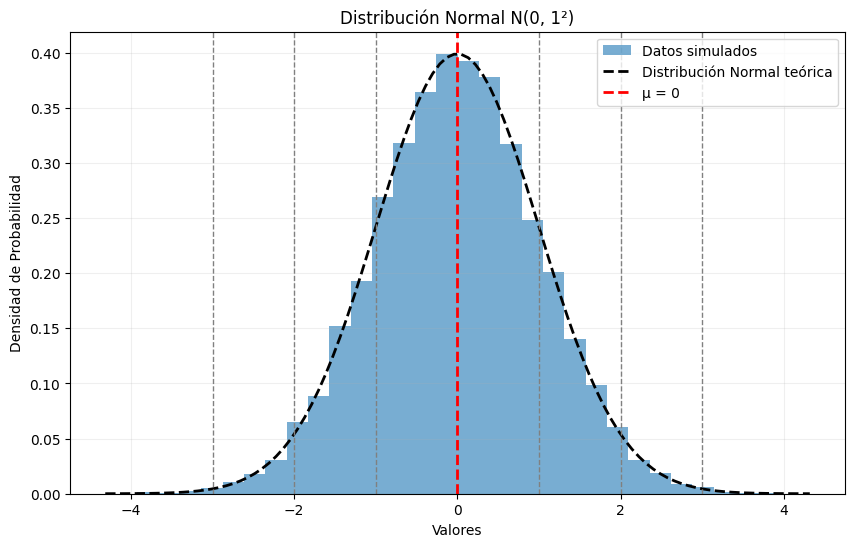

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


def generate_normal_data(mu, sigma, n=10000, seed=42):
    np.random.seed(seed)
    return np.random.normal(mu, sigma, n)


def calc_percents(datos, mu, sigma):
    pct_1sigma = np.mean((datos > mu - sigma) & (datos < mu + sigma)) * 100
    pct_2sigma = np.mean((datos > mu - 2*sigma) & (datos < mu + 2*sigma)) * 100
    pct_3sigma = np.mean((datos > mu - 3*sigma) & (datos < mu + 3*sigma)) * 100
    return pct_1sigma, pct_2sigma, pct_3sigma


def plot_dist(datos, mu, sigma):
    plt.figure(figsize=(10, 6))
    plt.hist(datos, bins=30, density=True, alpha=0.6, label="Datos simulados")

    # Curva teórica
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, sigma)
    plt.plot(x, p, 'k--', linewidth=2, label="Distribución Normal teórica")

    # Líneas de referencia
    plt.axvline(mu, color='red', linestyle='dashed', linewidth=2, label=f"μ = {mu}")
    for i in range(1, 4):
        plt.axvline(mu + i*sigma, color='gray', linestyle='dashed', linewidth=1)
        plt.axvline(mu - i*sigma, color='gray', linestyle='dashed', linewidth=1)

    plt.title(f"Distribución Normal N({mu}, {sigma}²)")
    plt.xlabel("Valores")
    plt.ylabel("Densidad de Probabilidad")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()


def plot_normal_dist(mu=0, sigma=1, n=10000):
    datos = generate_normal_data(mu, sigma, n)
    pct_1sigma, pct_2sigma, pct_3sigma = calc_percents(datos, mu, sigma)

    print(f"Distribución N({mu}, {sigma}^2):")
    print(f"{pct_1sigma:.2f}% (68% esperado)")
    print(f"{pct_2sigma:.2f}% (95% esperado)")
    print(f"{pct_3sigma:.2f}% (99.7% esperado)\n")

    plot_dist(datos, mu, sigma)


plot_normal_dist(mu=0, sigma=1)


## Ejercicio práctico
A partir del siguiente dataset de estudiantes, analiza:
- la variable = "reading score" y variable = "writing score"
- Compara las distribuciones visuales:
  - ¿Cuál se parece más a una campana normal?
  - ¿Hay sesgo (asimetría) o valores extremos?


Preguntas:
- ¿Dirías que los resultados siguen una distribución normal? ¿Por qué?
- ¿La media y la desviación estándar representan bien los datos?
- ¿Hay algo que llame la atención (por ejemplo, muchos alumnos con puntuaciones muy bajas o muy altas)?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargar dataset
df = pd.read_csv("https://raw.githubusercontent.com/pvbl/churn-modeling-telco-data/refs/heads/main/StudentsPerformance.csv")


In [ ]:

# TODO

### Estadísticos

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, skewnorm, laplace, uniform


def generar_datos(n=1000, a = 5, loc = 0, scale =1, seed= 123):
    """
    arg n: tamaño de la muesta
    arg a: asímetría
    arg loc: dónde está la media
    arg scale: dispersión
    arg seed: seed
    """
    np.random.seed(seed=seed)

    datos = skewnorm.rvs(a, loc=loc, scale=scale, size=n)

    return pd.Series(datos)


<Axes: ylabel='Frequency'>

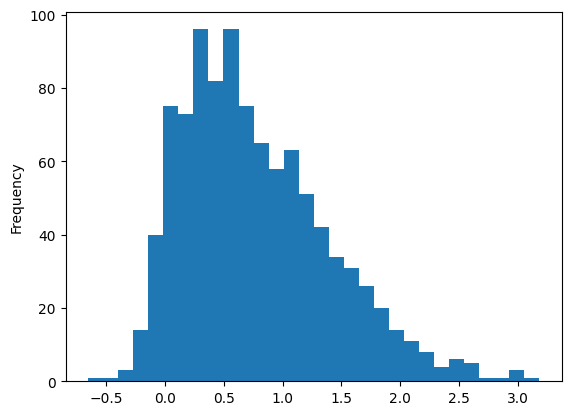

In [ ]:
ds1 = generar_datos()
ds1.plot(kind="hist",bins=30)

In [ ]:
ds1.describe()

,0
count,1000.000000
mean,0.774278
std,0.623763
min,-0.651454
25%,0.298565
50%,0.649378
75%,1.168408
max,3.178866


<Axes: ylabel='Frequency'>

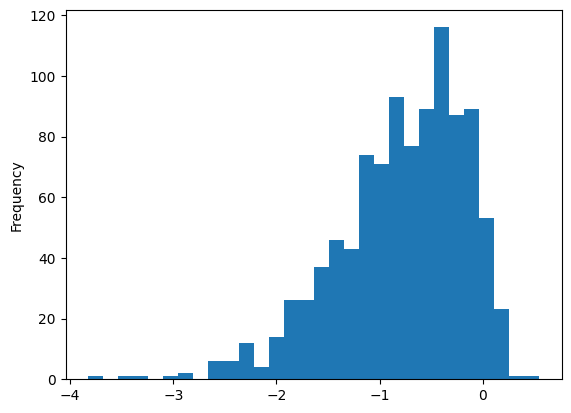

In [ ]:
ds2 = generar_datos(a=-5)
ds2.plot(kind="hist",bins=30)

In [ ]:
ds2.describe()

,0
count,1000.000000
mean,-0.786656
std,0.626968
min,-3.825577
25%,-1.164708
50%,-0.696332
75%,-0.321018
max,0.546996


### Ejercicio práctico
- Plotea la media, mediana, Q1 y Q5 de las distribuciones anteriores ds1 y ds2

In [ ]:
# TODO

### Análisis multivariante

In [ ]:

import numpy as np
import pandas as pd

def generar_datos(n=100, ruido=1, seed=42):
    """
    Genera dos variables:
    x = valores aleatorios
    y = x + ruido

    """
    np.random.seed(seed)
    x = np.random.rand(n)  # Valores uniformes entre 0 y 1
    y = x + np.random.normal(0, ruido, n)  # Añade ruido

    return pd.DataFrame({'x': x, 'y': y})


In [ ]:
generar_datos().corr()

,x,y
x,1.000000,0.175292
y,0.175292,1.000000


### Ejercicio
A partir del dataset de estudiantes anterior, calcula la correlación entre todas las variables reading score, writing score y math score.
- Haz una visualización de matriz de dispersión usando seaborn
- Haz un gráfico de Distribución de Tipos de Almuerzo por Género usando seaborn

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/pvbl/churn-modeling-telco-data/refs/heads/main/StudentsPerformance.csv")
# selecciona las variables y haz la correlación

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Crea una matriz de dispersión con seaborn

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# haz un gráfico 'Distribución de Tipos de Almuerzo por Género'


## Transformaciones

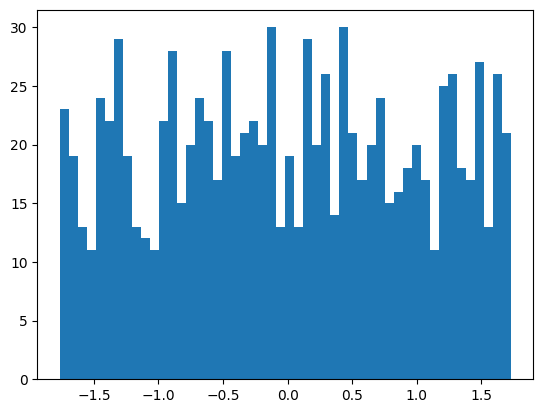

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import numpy as np

def generar_datos():
  # Generamos un dataset más grande con valores "normales"
  np.random.seed(42)
  datos = np.random.randint(0, 400, size=(1000, 1))

  # Añadimos  outliers
  #outliers = np.array([[500], [800], [1000], [1500]])

  # Unimos
  #datos = np.vstack((datos, outliers))
  return datos

datos = generar_datos()
# Estandarización
stand = StandardScaler().fit_transform(datos)


_ = plt.hist(stand,bins=50)

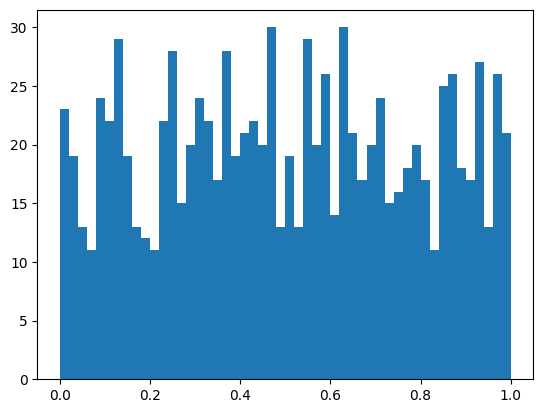

In [ ]:
# Normalización
minmax = MinMaxScaler().fit_transform(datos)

_ = plt.hist(minmax,bins=50)

### Ejercicio
Añade los outliers que están comentados en los datos anteriores y evalúa los resultados